# tempify — Caso real: WorldClim Alto Maipo, Chile

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djwillichile/tempify/blob/main/docs/tutorials/02-real-worldclim-maipo.ipynb)

**Densificación temporal sobre datos climáticos reales.**

Este cuaderno es el complemento aplicado de [`01-getting-started.ipynb`](https://colab.research.google.com/github/djwillichile/tempify/blob/main/docs/tutorials/01-getting-started.ipynb). En vez de un sample sintético, usamos un stack mensual de WorldClim v2.1 recortado a la **cuenca del Alto Maipo, Andes centrales de Chile** (126×147 píxeles, resolución 30 arc-sec ≈ 1 km, climatología 1970–2000).

El objetivo es mostrar dos cosas en menos de 3 minutos:

1. Tempify v0.1.2+ acepta directo un **GeoTIFF multibanda** (una banda por mes) sin que el usuario tenga que splittearlo a mano.
2. La curva PCHIP+RM produce un ciclo diario realista incluso en terreno con **alto contraste altitudinal** (de −18 °C en alta cordillera invernal a +23 °C en el valle estival).

> **Fuente del dataset.** WorldClim v2.1, climatología mensual de temperatura media 1970–2000 (Fick & Hijmans 2017). Disponible en https://www.worldclim.org bajo licencia CC-BY-SA 4.0. El recorte del Alto Maipo se distribuye con el repo de tempify por conveniencia.


## 1. Setup

Instalamos tempify desde el repositorio. Idempotente: si ya está disponible, se omite.

In [10]:
# En Google Colab: instala tempify desde el repositorio publico (~1 min la primera vez).
# Si ya esta instalado (clon local en modo editable), no hace nada.
try:
    import tempify  # noqa: F401
    print(f"tempify {tempify.__version__} ya esta instalado; se omite la instalacion.")
except ImportError:
    print("Instalando tempify desde GitHub...")
    from IPython import get_ipython
    get_ipython().run_line_magic(
        "pip",
        "install --upgrade git+https://github.com/djwillichile/tempify.git",
    )
    import tempify  # noqa: F401
    print(f"tempify {tempify.__version__} instalado.")


tempify 0.1.5 ya esta instalado; se omite la instalacion.


In [11]:
from __future__ import annotations

import shutil
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rioxarray  # noqa: F401  registers the rio accessor
import xarray as xr
from IPython.display import Markdown, display

import tempify
from tempify.pipeline import PipelineConfig, ReportGenerator, TempifyPipeline

print(f"tempify version: {tempify.__version__}")


tempify version: 0.1.5


## 2. Descargamos el stack WorldClim Alto Maipo

Un único GeoTIFF de 12 bandas (Ene–Dic), ~220 KB, en EPSG:4326.
Si ya está disponible (ejecución local), se omite la descarga.

In [12]:
DATA_URL = (
    "https://github.com/djwillichile/tempify/raw/main/"
    "examples/data/worldclim_maipo_alto/wc1_6_maipo_alto_tavg_stack.tif"
)
STACK_PATH = Path("wc_maipo_alto_tavg.tif")

if not STACK_PATH.exists():
    print(f"Descargando {DATA_URL} ...")
    urllib.request.urlretrieve(DATA_URL, STACK_PATH)
    print(f"  ok ({STACK_PATH.stat().st_size // 1024} KB)")
else:
    print(f"Ya disponible: {STACK_PATH} ({STACK_PATH.stat().st_size // 1024} KB)")

monthly = xr.load_dataarray(STACK_PATH)
print(f"\nDims: {monthly.dims}, shape: {monthly.shape}")
print(f"CRS: {monthly.rio.crs}")
print(f"Bounds: {monthly.rio.bounds()}")
print(f"Range temporal: 12 bandas (Ene-Dic), media climatologica 1970-2000")


Ya disponible: wc_maipo_alto_tavg.tif (214 KB)

Dims: ('band', 'y', 'x'), shape: (12, 126, 147)
CRS: EPSG:4326
Bounds: (-70.99224649415594, -34.08361171042349, -69.76723648891578, -33.03360313450336)
Range temporal: 12 bandas (Ene-Dic), media climatologica 1970-2000


## 3. Visualizamos los 12 meses observados

Cada raster es la temperatura media mensual climatológica para ese mes en el Alto Maipo. La paleta `RdYlBu_r` (azul → rojo) refleja temperatura: azules profundos son la alta cordillera invernal (puede bajar de −15 °C), rojos son el valle estival (~22 °C).

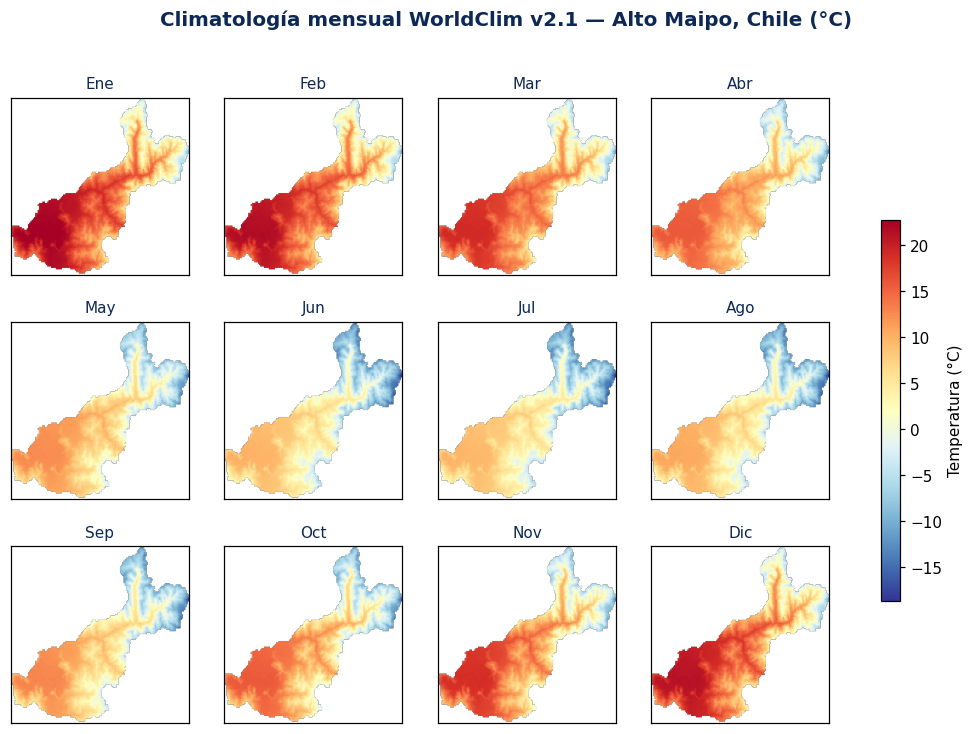

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(12, 7.5), dpi=110, sharex=True, sharey=True)
month_names = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
               "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
vmin = float(monthly.min())
vmax = float(monthly.max())
for i, ax in enumerate(axes.flat):
    raster = monthly.isel(band=i).values
    im = ax.imshow(raster, cmap="RdYlBu_r", vmin=vmin, vmax=vmax,
                   extent=monthly.rio.bounds()[::1])
    ax.set_title(month_names[i], fontsize=10, color="#0d2854")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(
    "Climatología mensual WorldClim v2.1 — Alto Maipo, Chile (°C)",
    fontsize=13, color="#0d2854", fontweight="bold", y=0.98,
)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label="Temperatura (°C)")
plt.show()


## 4. Ejecutamos el pipeline directamente sobre el stack multibanda

Acá está el punto clave: `tempify` acepta el `.tif` de 12 bandas sin que tengamos que partirlo en 12 archivos. La heurística "1 archivo con 12 bandas → climatológico" se aplica en `TemporalFrequencyResolver` (tier `count_heuristic`).

In [14]:
OUT_DIR = Path("out") / "maipo_pchip_mp"
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)

cfg = PipelineConfig(
    method="pchip_mp",
    target_year=2024,
    output_dir=OUT_DIR,
    output_format="netcdf",
)
result = TempifyPipeline(cfg).run(STACK_PATH)

print(f"Outputs: {[str(p) for p in result.outputs]}")
print(f"Estructura: {result.detection.structure_mode.name}")
print(
    f"Frecuencia: {result.frequency.frequency.value} "
    f"(tier: {result.frequency.tier_used.name}, confianza: {result.frequency.confidence:.2f})"
)
print(f"Evidencia: {result.frequency.source_evidence}")
print(f"Pre-validacion: {len(result.pre_validation.errors)} errores, {len(result.pre_validation.warnings)} warnings")
if result.post_validation is not None:
    print(f"Post-validacion: {len(result.post_validation.errors)} errores, {len(result.post_validation.warnings)} warnings")


Outputs: ['out/maipo_pchip_mp/tempify_output.nc']
Estructura: SINGLE_STACK
Frecuencia: climatological (tier: COUNT_HEURISTIC, confianza: 0.70)
Evidencia: heurística por bandas: 1 archivo con 12 bandas → climatological
Pre-validacion: 0 errores, 0 warnings
Post-validacion: 0 errores, 0 warnings


In [15]:
daily = xr.load_dataarray(result.outputs[0])
print(daily)
print()
print(f"Shape: {daily.shape}  (dims: {daily.dims})")
print(f"Rango temporal: {str(daily.time.values[0])[:10]} a {str(daily.time.values[-1])[:10]}")
print(f"Total timesteps: {daily.sizes['time']}")


<xarray.DataArray 'band_data' (y: 126, x: 147, time: 366)> Size: 54MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan,

## 5. Cuatro fechas representativas del output diario

El output es un cubo `(y, x, time)` con 365 ó 366 días. Visualizamos día 15 de Enero, Abril, Julio y Octubre para ver el ciclo anual reconstruido. Misma escala de colores que la climatología mensual.

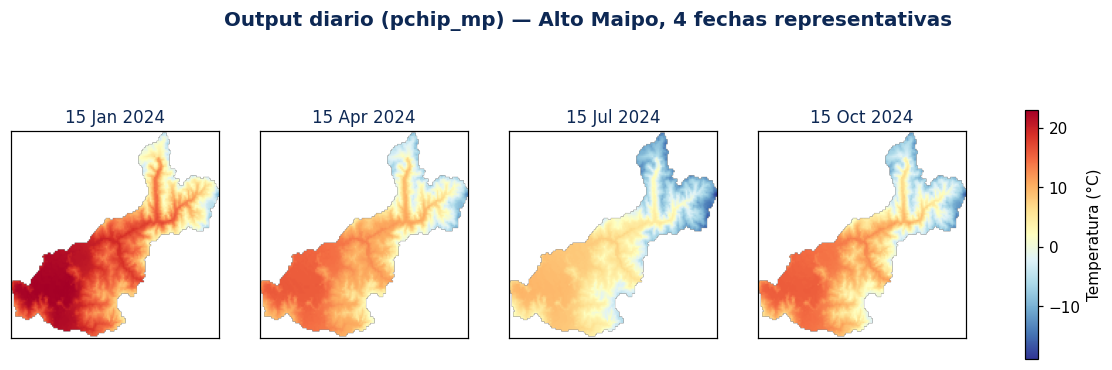

In [16]:
import datetime as _dt

dates = [_dt.date(2024, m, 15) for m in (1, 4, 7, 10)]
fig, axes = plt.subplots(1, 4, figsize=(14, 4.2), dpi=110, sharex=True, sharey=True)

vmin = float(daily.min())
vmax = float(daily.max())

for ax, date in zip(axes, dates):
    doy = date.timetuple().tm_yday - 1
    raster = daily.isel(time=doy).values
    im = ax.imshow(raster, cmap="RdYlBu_r", vmin=vmin, vmax=vmax,
                   extent=daily.rio.bounds()[::1] if hasattr(daily, "rio") else None)
    ax.set_title(date.strftime("%d %b %Y"), fontsize=11, color="#0d2854")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    "Output diario (pchip_mp) — Alto Maipo, 4 fechas representativas",
    fontsize=13, color="#0d2854", fontweight="bold",
)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7, label="Temperatura (°C)")
plt.show()


## 6. Ciclo anual: alta cordillera vs valle

El Alto Maipo tiene un gradiente altitudinal extremo en pocos kilómetros. Seleccionamos:

- **Píxel cordillera** (NE del grid, alta montaña, > 4 000 m): la columna más fría de cada mes.
- **Píxel valle** (SO del grid, fondo del valle del Maipo, ~800 m): la columna más cálida.

La amplitud térmica anual y el offset entre ambas series muestran cómo `pchip_mp` reconstruye fielmente dos regímenes climáticos completamente distintos a partir de los mismos 12 nodos mensuales.

Pixel cordillera: y=38, x=146  T_ene=-9.6 degC
Pixel valle:      y=96, x=33  T_ene=23.0 degC


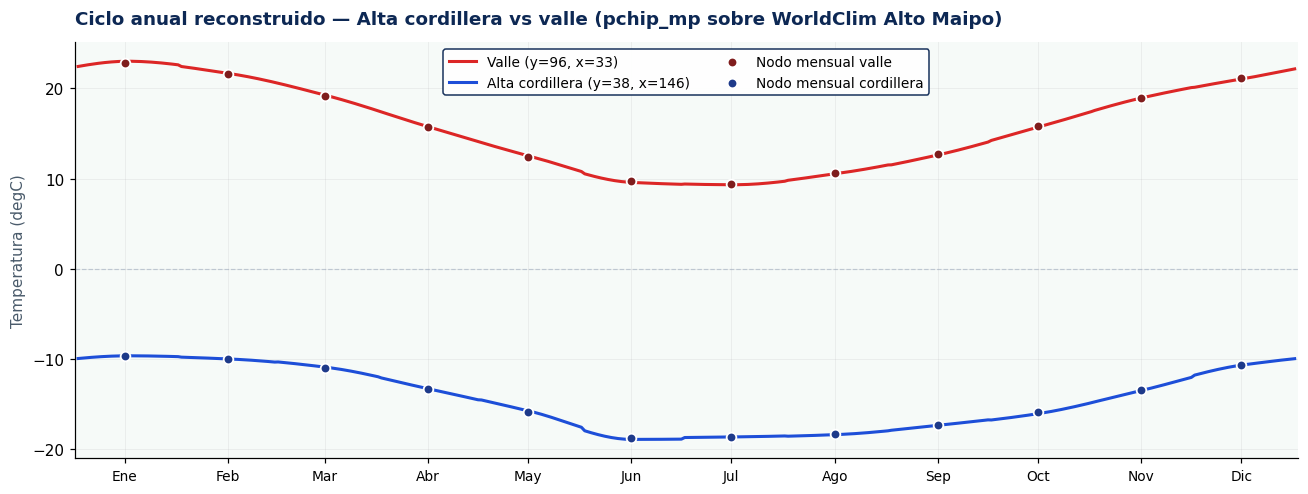


Amplitud termica anual valle:       13.7 degC
Amplitud termica anual cordillera:  9.3 degC
Offset medio valle vs cordillera:   30.2 degC


In [19]:
# Localizar pixel mas frio (cordillera) y mas calido (valle) en Enero como proxy de altitud.
# nanargmin/nanargmax excluyen pixeles sin datos (NaN fuera de la cuenca).
jan = daily.isel(time=14).values
iy_cold, ix_cold = np.unravel_index(np.nanargmin(jan), jan.shape)
iy_warm, ix_warm = np.unravel_index(np.nanargmax(jan), jan.shape)

series_cold = daily.isel(y=iy_cold, x=ix_cold).values
series_warm = daily.isel(y=iy_warm, x=ix_warm).values

# Verificacion: ningun NaN en las series seleccionadas
assert not np.isnan(series_cold).any(), f"Serie cordillera contiene NaN (y={iy_cold}, x={ix_cold})"
assert not np.isnan(series_warm).any(), f"Serie valle contiene NaN (y={iy_warm}, x={ix_warm})"

# Anclas mensuales (input WorldClim) en el mismo pixel para verificar pass-through.
month_doy = [int(_dt.date(2024, m, 15).timetuple().tm_yday) for m in range(1, 13)]
month_cold = monthly.isel(band=slice(0, 12), y=iy_cold, x=ix_cold).values
month_warm = monthly.isel(band=slice(0, 12), y=iy_warm, x=ix_warm).values

print(f"Pixel cordillera: y={iy_cold}, x={ix_cold}  T_ene={jan[iy_cold, ix_cold]:.1f} degC")
print(f"Pixel valle:      y={iy_warm}, x={ix_warm}  T_ene={jan[iy_warm, ix_warm]:.1f} degC")

fig, ax = plt.subplots(figsize=(12, 4.6), dpi=110)
fig.patch.set_facecolor("#ffffff")
ax.set_facecolor("#f6faf8")
doy_all = np.arange(1, daily.sizes["time"] + 1)
ax.plot(doy_all, series_warm, color="#dc2626", linewidth=2.0, label=f"Valle (y={iy_warm}, x={ix_warm})", zorder=3)
ax.plot(doy_all, series_cold, color="#1d4ed8", linewidth=2.0, label=f"Alta cordillera (y={iy_cold}, x={ix_cold})", zorder=3)
ax.scatter(month_doy, month_warm, color="#7f1d1d", s=40, edgecolors="white", linewidth=1.2, zorder=4, label="Nodo mensual valle")
ax.scatter(month_doy, month_cold, color="#1e3a8a", s=40, edgecolors="white", linewidth=1.2, zorder=4, label="Nodo mensual cordillera")

ax.set_xlim(0, daily.sizes["time"] + 1)
ax.set_xticks([int(_dt.date(2024, m, 15).timetuple().tm_yday) for m in range(1, 13)])
ax.set_xticklabels(["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"], fontsize=9)
ax.axhline(0, color="#94a3b8", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_ylabel("Temperatura (degC)", color="#4a5b6b", fontsize=10)
ax.set_title(
    "Ciclo anual reconstruido — Alta cordillera vs valle (pchip_mp sobre WorldClim Alto Maipo)",
    color="#0d2854", fontsize=12, fontweight="bold", pad=12, loc="left",
)
ax.grid(True, alpha=0.18, linewidth=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper center", framealpha=0.95, fontsize=9, edgecolor="#0d2854", ncol=2)
plt.tight_layout()
plt.show()

print()
print(f"Amplitud termica anual valle:       {series_warm.max() - series_warm.min():.1f} degC")
print(f"Amplitud termica anual cordillera:  {series_cold.max() - series_cold.min():.1f} degC")
print(f"Offset medio valle vs cordillera:   {series_warm.mean() - series_cold.mean():.1f} degC")


## 7. Reporte de procedencia

Cada ejecución produce un `ProcessingReport` con versión, timestamp UTC, MD5 inputs/outputs, configuración y métricas. Lo renderizamos en Markdown para ver la trazabilidad.

In [18]:
rg = ReportGenerator()
report_md = rg.to_markdown(result.report)
display(Markdown(report_md))


# Reporte de procesamiento tempify

- **Versión tempify:** 0.1.5
- **Timestamp UTC:** 2026-05-18T20:21:31+00:00
- **Método:** `pchip_mp`
- **Año destino:** 2024
- **Modo de estructura:** A
- **Frecuencia temporal inferida:** climatological

## Confianza de detección

- structure_mode: 1.00
- homogeneity: 1.00

## Validación pre-procesamiento

- Errores: 0
- Advertencias: 0
- Info: 6

## Validación post-procesamiento

- Errores: 0
- Advertencias: 0
- Info: 4

## Archivos de entrada

- `wc_maipo_alto_tavg.tif`

## Archivos de salida

- `out/maipo_pchip_mp/tempify_output.nc`


## 8. Lectura y cita

**Lo que viste**

- El stack mensual de WorldClim v2.1 (12 valores climatológicos, 1970–2000) se densificó a 366 valores diarios para el año 2024.
- La curva PCHIP+RM (`pchip_mp`) preserva la media mensual con error `< 10⁻⁴ °C` y produce un ciclo C¹ continuo entre Diciembre y Enero gracias al climatological wraparound (ADR-0016).
- El gradiente altitudinal extremo se mantuvo: valle del Maipo y alta cordillera son interpolados independientemente por píxel.

**Cómo citar este dataset**

```text
Fick, S. E., & Hijmans, R. J. (2017). WorldClim 2: new 1-km spatial
resolution climate surfaces for global land areas. International Journal
of Climatology, 37(12), 4302-4315. https://doi.org/10.1002/joc.5086
```

**Cómo citar tempify**

```text
Fuentes-Jaque, G. S. (2026). tempify: Temporal densification for
geospatial raster stacks (v0.1.2) [Software]. ICTA Ltda.
https://doi.org/10.5281/zenodo.20251750
```

**Próximos pasos**

- Ver el [tutorial introductorio](https://colab.research.google.com/github/djwillichile/tempify/blob/main/docs/tutorials/01-getting-started.ipynb) con el sample sintético y comparación de los 4 métodos de interpolación.
- Revisar el [repositorio en GitHub](https://github.com/djwillichile/tempify) para la API completa, ADRs y especificaciones SDD.
- Aplicar el mismo flujo a tus propios stacks mensuales WorldClim/CHELSA/CRU-TS/TerraClimate.
